In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
cadastrados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_cadastrados.csv?raw=True')

In [3]:
cadastrados.head()

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0
3,5008808,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0
4,5008809,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0


In [4]:
cadastrados.shape

(438557, 18)

In [5]:
cadastrados['ID_Cliente'].value_counts()

ID_Cliente
7137299    2
7702238    2
7282535    2
7243768    2
7050948    2
          ..
5690727    1
6621262    1
6621261    1
6621260    1
6842885    1
Name: count, Length: 438510, dtype: int64

In [6]:
id_repetidos = cadastrados[cadastrados['ID_Cliente'].duplicated(keep=False)]

In [7]:
df_cadastrados_limpo = cadastrados.drop(id_repetidos.index)

In [8]:
df_cadastrados_limpo['ID_Cliente'].value_counts()

ID_Cliente
5008804    1
6147691    1
6147689    1
6147688    1
6147685    1
          ..
6093492    1
5690720    1
6538938    1
6538937    1
6842885    1
Name: count, Length: 438463, dtype: int64

In [9]:
df_cadastrados_limpo.isnull().sum().sort_values(ascending=False)

Ocupacao                 134177
ID_Cliente                    0
Genero                        0
Tem_email                     0
Tem_telefone_fixo             0
Tem_telefone_trabalho         0
Tem_celular                   0
Anos_empregado                0
Idade                         0
Moradia                       0
Estado_civil                  0
Grau_escolaridade             0
Categoria_de_renda            0
Rendimento_anual              0
Qtd_filhos                    0
Tem_casa_propria              0
Tem_carro                     0
Tamanho_familia               0
dtype: int64

In [10]:
df_cadastrados_limpo['Ocupacao'].unique()

array([nan, 'Segurança', 'Vendas', 'Contabilidade', 'Construção Civil',
       'Gerência', 'Motorista', 'Equipe principal', 'Alta tecnologia',
       'Limpeza', 'Serviço privado', 'Cozinha', 'Baixa qualificação',
       'Medicina', 'Secretariado', 'Garçom', 'RH', 'Corretor imobiliário',
       'TI'], dtype=object)

In [11]:
df_cadastrados_limpo['Ocupacao'].fillna(value='Outro',inplace=True)

In [12]:
df_cadastrados_limpo.isnull().sum().sort_values(ascending=False)

ID_Cliente               0
Genero                   0
Ocupacao                 0
Tem_email                0
Tem_telefone_fixo        0
Tem_telefone_trabalho    0
Tem_celular              0
Anos_empregado           0
Idade                    0
Moradia                  0
Estado_civil             0
Grau_escolaridade        0
Categoria_de_renda       0
Rendimento_anual         0
Qtd_filhos               0
Tem_casa_propria         0
Tem_carro                0
Tamanho_familia          0
dtype: int64

In [13]:
df_cadastrados_limpo.nunique().sort_values(ascending=False)

ID_Cliente               438463
Idade                     16379
Anos_empregado             9406
Rendimento_anual            866
Ocupacao                     19
Tamanho_familia              13
Qtd_filhos                   12
Moradia                       6
Categoria_de_renda            5
Grau_escolaridade             5
Estado_civil                  5
Genero                        2
Tem_casa_propria              2
Tem_telefone_trabalho         2
Tem_telefone_fixo             2
Tem_email                     2
Tem_carro                     2
Tem_celular                   1
dtype: int64

In [14]:
df_cadastrados_limpo.drop('Genero', axis=1, inplace=True)

In [15]:
df_cadastrados_limpo.drop('Tem_celular', axis=1, inplace=True)

In [16]:
df_cadastrados_limpo.columns

Index(['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 'Qtd_filhos',
       'Rendimento_anual', 'Categoria_de_renda', 'Grau_escolaridade',
       'Estado_civil', 'Moradia', 'Idade', 'Anos_empregado',
       'Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email', 'Ocupacao',
       'Tamanho_familia'],
      dtype='object')

In [17]:
df_cadastrados_limpo['Tem_carro'].unique()

array(['Y', 'N'], dtype=object)

In [18]:
df_cadastrados_limpo['Tem_casa_propria'].unique()

array(['Y', 'N'], dtype=object)

In [19]:
df_cadastrados_limpo['Tem_telefone_trabalho'].unique()

array([1, 0], dtype=int64)

In [20]:
df_cadastrados_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438463 entries, 0 to 438556
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID_Cliente             438463 non-null  int64  
 1   Tem_carro              438463 non-null  object 
 2   Tem_casa_propria       438463 non-null  object 
 3   Qtd_filhos             438463 non-null  int64  
 4   Rendimento_anual       438463 non-null  float64
 5   Categoria_de_renda     438463 non-null  object 
 6   Grau_escolaridade      438463 non-null  object 
 7   Estado_civil           438463 non-null  object 
 8   Moradia                438463 non-null  object 
 9   Idade                  438463 non-null  int64  
 10  Anos_empregado         438463 non-null  int64  
 11  Tem_telefone_trabalho  438463 non-null  int64  
 12  Tem_telefone_fixo      438463 non-null  int64  
 13  Tem_email              438463 non-null  int64  
 14  Ocupacao               438463 non-null  o

In [21]:
df_cadastrados_limpo['Tem_carro'] = df_cadastrados_limpo['Tem_carro'].replace(['Y', 'N'], [1, 0])

In [22]:
df_cadastrados_limpo['Tem_casa_propria'] = df_cadastrados_limpo['Tem_casa_propria'].replace(['Y', 'N'], [1, 0])

In [23]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,0,0,0,Segurança,2.0
3,5008808,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0
4,5008809,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0


In [24]:
df_cadastrados_limpo['Idade'] = - df_cadastrados_limpo['Idade'] / 365.2425

In [25]:
df_cadastrados_limpo['Anos_empregado'] = - df_cadastrados_limpo['Anos_empregado'] / 365.2425

In [26]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
-1000.001369    75314
 0.596864         262
 4.594208         251
 0.681739         241
 2.677673         240
                ...  
 37.041144          1
 27.989623          1
 24.413917          1
 31.291539          1
 22.190736          1
Name: count, Length: 9406, dtype: int64

In [27]:
df_cadastrados_limpo.loc[df_cadastrados_limpo['Anos_empregado'] < 0, 'Anos_empregado'] = 0

In [28]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
0.000000     75314
0.596864       262
4.594208       251
0.681739       241
2.677673       240
             ...  
37.041144        1
27.989623        1
24.413917        1
31.291539        1
22.190736        1
Name: count, Length: 9406, dtype: int64

In [29]:
df_cadastrados_limpo.dtypes

ID_Cliente                 int64
Tem_carro                  int64
Tem_casa_propria           int64
Qtd_filhos                 int64
Rendimento_anual         float64
Categoria_de_renda        object
Grau_escolaridade         object
Estado_civil              object
Moradia                   object
Idade                    float64
Anos_empregado           float64
Tem_telefone_trabalho      int64
Tem_telefone_fixo          int64
Tem_email                  int64
Ocupacao                  object
Tamanho_familia          float64
dtype: object

<AxesSubplot: >

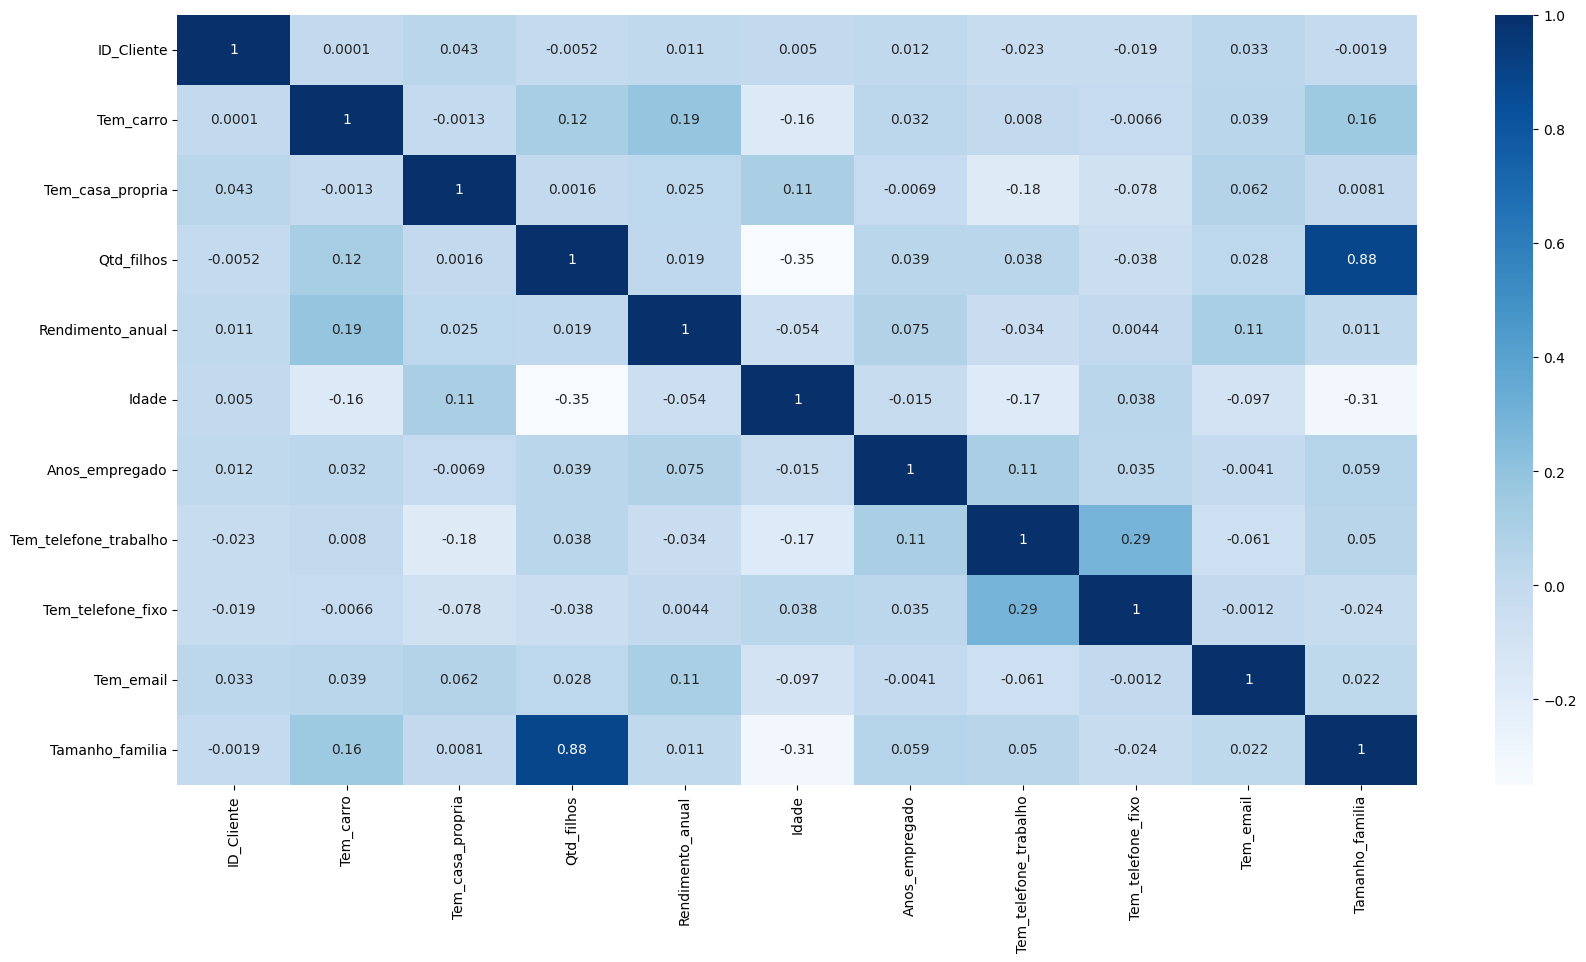

In [30]:
corr = df_cadastrados_limpo.select_dtypes(include=['number']).corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap='Blues', annot=True)

In [31]:
df_cadastrados_limpo.drop(['Qtd_filhos'], axis=1, inplace=True)

In [32]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
1,5008805,1,1,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
2,5008806,1,1,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,58.793815,3.104787,0,0,0,Segurança,2.0
3,5008808,0,1,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,0,1,1,Vendas,1.0
4,5008809,0,1,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,0,1,1,Vendas,1.0


In [33]:
df_cadastrados_limpo = df_cadastrados_limpo[['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 'Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email', 'Tamanho_familia'
                                             ,'Rendimento_anual', 'Idade', 'Anos_empregado', 'Categoria_de_renda', 'Grau_escolaridade', 'Estado_civil', 'Moradia', 'Ocupacao']]

In [34]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao
0,5008804,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
1,5008805,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
2,5008806,1,1,0,0,0,2.0,112500.0,58.793815,3.104787,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança
3,5008808,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas
4,5008809,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas


In [35]:
df_cadastrados_limpo['Categoria_de_renda'].value_counts(normalize=True)*100

Categoria_de_renda
Empregado              51.557144
Associado comercial    22.972520
Pensionista            17.214223
Servidor público        8.252236
Estudante               0.003877
Name: proportion, dtype: float64

In [36]:
aprovados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_aprovados.csv?raw=True')

In [37]:
aprovados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID_Cliente      1048575 non-null  int64 
 1   Mes_referencia  1048575 non-null  int64 
 2   Faixa_atraso    1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [38]:
aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias
3,5001711,-3,1-29 dias
4,5001712,0,pagamento realizado


In [39]:
aprovados.query('ID_Cliente == 5001712')

,ID_Cliente,Mes_referencia,Faixa_atraso
4,5001712,0,pagamento realizado
5,5001712,-1,pagamento realizado
6,5001712,-2,pagamento realizado
7,5001712,-3,pagamento realizado
8,5001712,-4,pagamento realizado
9,5001712,-5,pagamento realizado
10,5001712,-6,pagamento realizado
11,5001712,-7,pagamento realizado
12,5001712,-8,pagamento realizado
13,5001712,-9,1-29 dias


In [40]:
aprovados.query('ID_Cliente == 5001711')

,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias
3,5001711,-3,1-29 dias


In [41]:
aprovados.Faixa_atraso.value_counts()

Faixa_atraso
pagamento realizado    442031
1-29 dias              383120
nenhum empréstimo      209230
30-59 dias              11090
>150 dias                1693
60-89 dias                868
90-119 dias               320
120-149 dias              223
Name: count, dtype: int64

In [42]:
df_registros_credito_agrupados_ID = aprovados.groupby('ID_Cliente')
ser_abertura = df_registros_credito_agrupados_ID.apply(lambda x: min(x['Mes_referencia']))
ser_abertura.name = 'Abertura'
ser_abertura.head

<bound method NDFrame.head of ID_Cliente
5001711    -3
5001712   -18
5001713   -21
5001714   -14
5001715   -59
           ..
5150482   -28
5150483   -17
5150484   -12
5150485    -1
5150487   -29
Name: Abertura, Length: 45985, dtype: int64>

In [43]:
df_clientes_aprovados = aprovados.merge(ser_abertura, on='ID_Cliente')
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura
0,5001711,0,nenhum empréstimo,-3
1,5001711,-1,1-29 dias,-3
2,5001711,-2,1-29 dias,-3
3,5001711,-3,1-29 dias,-3
4,5001712,0,pagamento realizado,-18


In [44]:
ser_final = df_registros_credito_agrupados_ID.apply(lambda x: max(x['Mes_referencia']))
ser_final.name = 'Final'
ser_final

ID_Cliente
5001711     0
5001712     0
5001713     0
5001714     0
5001715     0
           ..
5150482   -11
5150483     0
5150484     0
5150485     0
5150487     0
Name: Final, Length: 45985, dtype: int64

In [45]:
df_clientes_aprovados = df_clientes_aprovados.merge(ser_final, on='ID_Cliente')
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final
0,5001711,0,nenhum empréstimo,-3,0
1,5001711,-1,1-29 dias,-3,0
2,5001711,-2,1-29 dias,-3,0
3,5001711,-3,1-29 dias,-3,0
4,5001712,0,pagamento realizado,-18,0


In [46]:
df_clientes_aprovados['Janela'] = df_clientes_aprovados['Final'] - df_clientes_aprovados['Abertura']
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela
0,5001711,0,nenhum empréstimo,-3,0,3
1,5001711,-1,1-29 dias,-3,0,3
2,5001711,-2,1-29 dias,-3,0,3
3,5001711,-3,1-29 dias,-3,0,3
4,5001712,0,pagamento realizado,-18,0,18


In [47]:
df_clientes_aprovados['MOB'] = df_clientes_aprovados['Mes_referencia'] - df_clientes_aprovados['Abertura']

In [48]:
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB
0,5001711,0,nenhum empréstimo,-3,0,3,3
1,5001711,-1,1-29 dias,-3,0,3,2
2,5001711,-2,1-29 dias,-3,0,3,1
3,5001711,-3,1-29 dias,-3,0,3,0
4,5001712,0,pagamento realizado,-18,0,18,18


In [49]:
df_clientes_aprovados['Faixa_atraso'].unique()

array(['nenhum empréstimo', '1-29 dias', 'pagamento realizado',
       '30-59 dias', '60-89 dias', '90-119 dias', '120-149 dias',
       '>150 dias'], dtype=object)

In [50]:
dict_faixa_atraso_ind = {
  'nenhum empréstimo' :0, 'pagamento realizado' :1, '1-29 dias' :2, '30-59 dias' :3, '60-89 dias' :4, '90-119 dias' :5, '120-149 dias' :6, '>150 dias' :7
}

In [51]:
df_clientes_aprovados['Ind_Faixa_atraso'] = df_clientes_aprovados['Faixa_atraso'].map(dict_faixa_atraso_ind)
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atraso
0,5001711,0,nenhum empréstimo,-3,0,3,3,0
1,5001711,-1,1-29 dias,-3,0,3,2,2
2,5001711,-2,1-29 dias,-3,0,3,1,2
3,5001711,-3,1-29 dias,-3,0,3,0,2
4,5001712,0,pagamento realizado,-18,0,18,18,1


In [52]:
df_clientes_aprovados['Mau'] = df_clientes_aprovados.apply(lambda x: 1 if x['Ind_Faixa_atraso'] > 3 else 0, axis=1)

In [53]:
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atraso,Mau
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,0
1,5001711,-1,1-29 dias,-3,0,3,2,2,0
2,5001711,-2,1-29 dias,-3,0,3,1,2,0
3,5001711,-3,1-29 dias,-3,0,3,0,2,0
4,5001712,0,pagamento realizado,-18,0,18,18,1,0


In [54]:
df_registros_creditos_ID = df_clientes_aprovados[['ID_Cliente', 'Abertura', 'Final', 'Janela']].groupby('ID_Cliente').apply(lambda x: x.iloc[0]).reset_index(drop=True)

In [55]:
df_registros_creditos_ID

,ID_Cliente,Abertura,Final,Janela
0,5001711,-3,0,3
1,5001712,-18,0,18
2,5001713,-21,0,21
3,5001714,-14,0,14
4,5001715,-59,0,59
...,...,...,...,...
45980,5150482,-28,-11,17
45981,5150483,-17,0,17
45982,5150484,-12,0,12
45983,5150485,-1,0,1


In [56]:
df_denominador = df_registros_creditos_ID.groupby('Abertura').apply(lambda x: x['ID_Cliente'].count()).reset_index()
df_denominador.columns = ['Abertura', 'Qtd_Cliente']
df_denominador

,Abertura,Qtd_Cliente
0,-60,415
1,-59,406
2,-58,440
3,-57,400
4,-56,470
...,...,...
56,-4,874
57,-3,919
58,-2,771
59,-1,686


In [57]:
df_vintage = df_clientes_aprovados.groupby(['Abertura', 'MOB']).apply(lambda x: x['ID_Cliente'].count()).reset_index()
df_vintage.columns = ['Abertura', 'MOB', 'Qtd_Clientes']
df_vintage

,Abertura,MOB,Qtd_Clientes
0,-60,0,415
1,-60,1,414
2,-60,2,410
3,-60,3,408
4,-60,4,403
...,...,...,...
1886,-2,1,770
1887,-2,2,750
1888,-1,0,686
1889,-1,1,682


In [58]:
df_vintage = pd.merge(df_vintage[['Abertura', 'MOB']], df_denominador, on='Abertura', how = 'left')

In [59]:
df_vintage

,Abertura,MOB,Qtd_Cliente
0,-60,0,415
1,-60,1,415
2,-60,2,415
3,-60,3,415
4,-60,4,415
...,...,...,...
1886,-2,1,771
1887,-2,2,771
1888,-1,0,686
1889,-1,1,686


In [60]:
df_vintage['Qtd_Mau'] = np.nan

for j in range (-60, 1):
  ls = []
  for i in range (0, 61):
    due = list(df_clientes_aprovados.query('Mau == 1 and MOB ==@i and Abertura == @j')['ID_Cliente'])
    ls.extend(due)
    df_vintage.loc[(df_vintage['MOB'] == i) & (df_vintage['Abertura'] == j), 'Qtd_Mau'] = len(set(ls))
                   
df_vintage['Taxa_de_Mau'] = df_vintage['Qtd_Mau'] / df_vintage['Qtd_Cliente']

df_vintage

,Abertura,MOB,Qtd_Cliente,Qtd_Mau,Taxa_de_Mau
0,-60,0,415,0.0,0.000000
1,-60,1,415,0.0,0.000000
2,-60,2,415,0.0,0.000000
3,-60,3,415,0.0,0.000000
4,-60,4,415,0.0,0.000000
...,...,...,...,...,...
1886,-2,1,771,0.0,0.000000
1887,-2,2,771,1.0,0.001297
1888,-1,0,686,0.0,0.000000
1889,-1,1,686,0.0,0.000000


In [61]:
df_vintage_pivot = df_vintage.pivot(index = 'Abertura',
                                    columns = 'MOB',
                                    values = 'Taxa_de_Mau')
df_vintage_pivot

MOB,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
Abertura,,,,,,,,,,,,,,,,,,,,,
-60,0.0,0.0,0.000000,0.000000,0.000000,0.002410,0.002410,0.007229,0.007229,0.009639,...,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.031325,0.031325,0.031325
-59,0.0,0.0,0.000000,0.004926,0.004926,0.004926,0.007389,0.007389,0.007389,0.012315,...,0.029557,0.029557,0.029557,0.032020,0.032020,0.032020,0.032020,0.032020,0.032020,NaN
-58,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.004545,0.006818,0.006818,...,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN
-57,0.0,0.0,0.000000,0.000000,0.002500,0.002500,0.002500,0.007500,0.007500,0.007500,...,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN,NaN
-56,0.0,0.0,0.004255,0.004255,0.008511,0.010638,0.010638,0.017021,0.017021,0.021277,...,0.036170,0.036170,0.036170,0.036170,0.038298,0.038298,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-4,0.0,0.0,0.000000,0.003432,0.003432,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3,0.0,0.0,0.001088,0.001088,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2,0.0,0.0,0.001297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


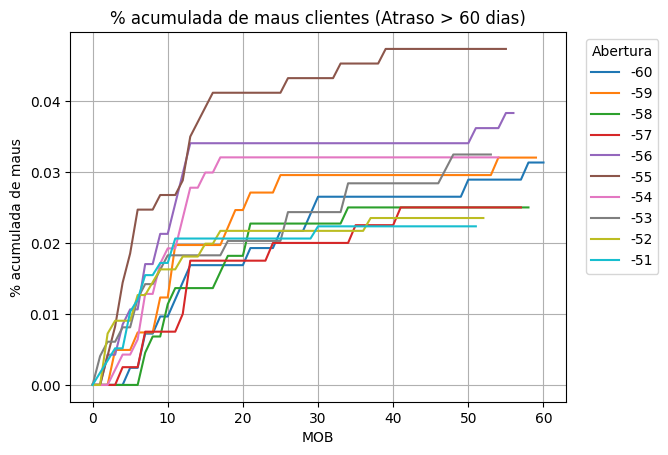

In [62]:
lst = [i for i in range(0, 61)]
df_vintage_pivot[lst].T.iloc[:, :10].plot(
  legend=True, 
  grid=True,
  title = '% acumulada de maus clientes (Atraso > 60 dias)'
)
plt.xlabel('MOB')
plt.ylabel('% acumulada de maus')
plt.legend(bbox_to_anchor=(1.2, 1), title='Abertura')
plt.show()

Text(0, 0.5, 'Percentual de clientes')

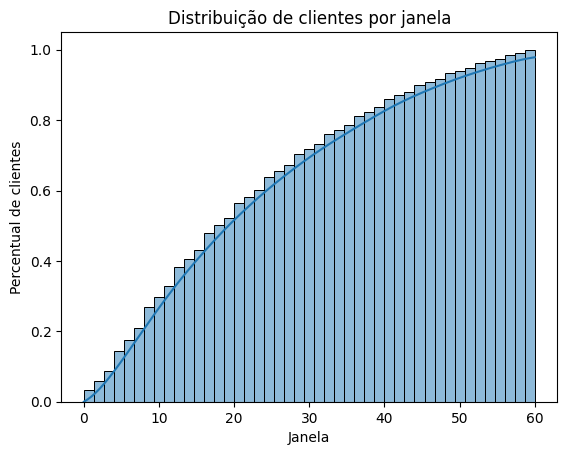

In [63]:
sns.histplot(data=df_registros_creditos_ID, x='Janela', cumulative=True, stat='density', kde=True)
plt.title('Distribuição de clientes por janela')
plt.xlabel('Janela')
plt.ylabel('Percentual de clientes') 

In [64]:
dict_intervalo_atraso = {'maior_30_dias': 3, 'maior_60_dias': 4, 'maior_90_dias':5, 'maior_120_dias':6, 'maior_150_dias': 7}

In [65]:
for chave, valor in dict_intervalo_atraso.items(): 
  df_clientes_aprovados[f'Mau_{chave}'] = df_clientes_aprovados.apply(lambda x:1 if x['Ind_Faixa_atraso'] >= valor else 0, axis=1)

df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atraso,Mau,Mau_maior_30_dias,Mau_maior_60_dias,Mau_maior_90_dias,Mau_maior_120_dias,Mau_maior_150_dias
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,0,0,0,0,0,0
1,5001711,-1,1-29 dias,-3,0,3,2,2,0,0,0,0,0,0
2,5001711,-2,1-29 dias,-3,0,3,1,2,0,0,0,0,0,0
3,5001711,-3,1-29 dias,-3,0,3,0,2,0,0,0,0,0,0
4,5001712,0,pagamento realizado,-18,0,18,18,1,0,0,0,0,0,0


In [66]:
dict_taxa_mau = {}
id_sum = len(set(df_clientes_aprovados['ID_Cliente']))

for chave in dict_intervalo_atraso.keys():
  df_min_mau = df_clientes_aprovados.query(f'Mau_{chave} == 1').groupby('ID_Cliente')['MOB'].min().reset_index()
  df_mob_taxa_mau = pd.DataFrame({'MOB':range(0,61), 'Taxa_Mau': np.nan})
  lst = []
  for i in range(0,61):
      due = df_min_mau.query('MOB == @i')['ID_Cliente'].to_list()
      lst.extend(due) #cumsum
      df_mob_taxa_mau.loc[df_mob_taxa_mau['MOB'] == i, 'Taxa_Mau'] = len(set(lst)) / id_sum
  dict_taxa_mau[chave] = df_mob_taxa_mau['Taxa_Mau']

df_taxa_mau = pd.DataFrame(dict_taxa_mau)
df_taxa_mau

,maior_30_dias,maior_60_dias,maior_90_dias,maior_120_dias,maior_150_dias
0,0.000304,0.000022,0.000022,0.000022,0.000022
1,0.011612,0.000174,0.000087,0.000087,0.000087
2,0.025878,0.001153,0.000196,0.000174,0.000174
3,0.036860,0.002240,0.000696,0.000304,0.000304
4,0.047385,0.003392,0.001044,0.000696,0.000348
...,...,...,...,...,...
56,0.116321,0.014483,0.007176,0.005263,0.004219
57,0.116321,0.014483,0.007176,0.005263,0.004219
58,0.116321,0.014505,0.007198,0.005284,0.004241
59,0.116321,0.014505,0.007198,0.005284,0.004241


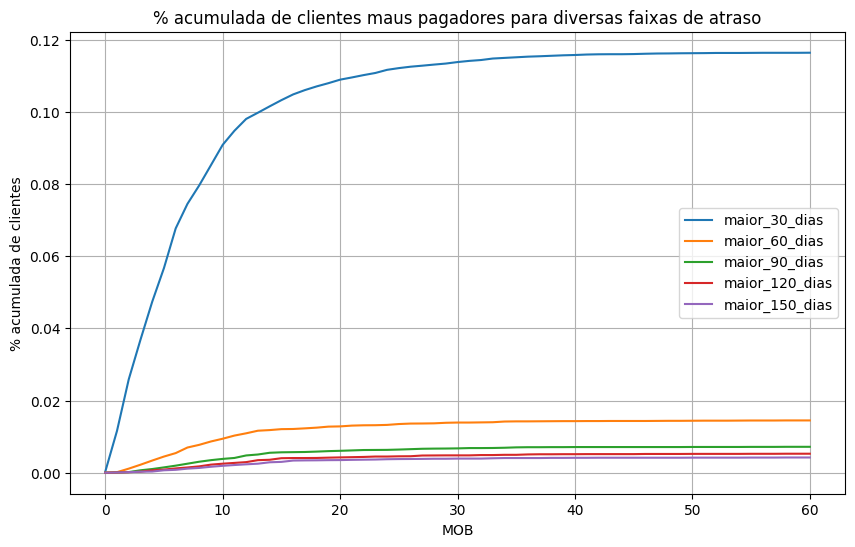

In [67]:
df_taxa_mau.plot(grid=True, title='% acumulada de clientes maus pagadores para diversas faixas de atraso', figsize=(10,6))
plt.xlabel('MOB')
plt.ylabel('% acumulada de clientes')
plt.show()


In [68]:
df_clientes_aprovados.tratamento1 = df_clientes_aprovados.query('Janela >= 12')

In [69]:
df_clientes_aprovados.tratamento1['Faixa_atraso'].unique()

array(['pagamento realizado', '1-29 dias', 'nenhum empréstimo',
       '30-59 dias', '60-89 dias', '90-119 dias', '120-149 dias',
       '>150 dias'], dtype=object)

In [70]:
def verifica(registros):
  lista_status = registros['Faixa_atraso'].to_list()
  if '60-89 dias' in lista_status or '90-119 dias' in lista_status or '120-149 dias' in lista_status or '>150 dias' in lista_status:
    return 1
  else:
    return 0

df_registros_creditos_id = pd.DataFrame(df_clientes_aprovados.tratamento1.groupby('ID_Cliente').apply(verifica)).reset_index()

df_registros_creditos_id.columns = ['ID_Cliente', 'Mau']

In [71]:
df_registros_creditos_id.head()

,ID_Cliente,Mau
0,5001712,0
1,5001713,0
2,5001714,0
3,5001715,0
4,5001717,0


In [72]:
df_registros_clientes_targets = df_cadastrados_limpo.merge(df_registros_creditos_id, on = 'ID_Cliente')

In [73]:
df_registros_clientes_targets.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao,Mau
0,5008804,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro,0
1,5008805,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro,0
2,5008806,1,1,0,0,0,2.0,112500.0,58.793815,3.104787,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança,0
3,5008810,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas,0
4,5008811,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas,0


In [74]:
df_registros_clientes_targets['Mau'].value_counts(normalize=True)*100

Mau
0    97.71126
1     2.28874
Name: proportion, dtype: float64

In [75]:
SEED = 1561651

In [76]:
df_treino, df_test = train_test_split(df_registros_clientes_targets, test_size=0.2, random_state=SEED)

In [77]:
df_treino.shape

(18735, 16)

In [78]:
df_test.shape

(4684, 16)

In [79]:
df_treino_copy = df_treino.copy()
df_test_copy = df_test.copy()

In [80]:
df_treino.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)

In [81]:
df_treino.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao,Mau
12599,5088863,1,1,0,0,1,2.0,270000.0,56.518614,17.675928,Empregado,Ensino superior,Casado,Casa/apartamento próprio,Equipe principal,0
1633,5021997,0,1,0,0,1,2.0,90000.0,51.645140,4.501119,Associado comercial,Ensino médio,Casado,Casa/apartamento próprio,Outro,0
9532,5061658,0,0,0,0,0,1.0,252000.0,62.328453,0.000000,Pensionista,Ensino médio,Viúvo,Casa/apartamento próprio,Outro,0
19671,5126096,0,1,0,1,0,2.0,157500.0,57.416648,0.000000,Pensionista,Ensino médio,Casado,Casa/apartamento próprio,Outro,0
17651,5114496,0,1,0,0,1,2.0,85500.0,56.964893,0.000000,Pensionista,Ensino médio,Casado,Casa/apartamento próprio,Outro,0


In [82]:

class DropFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,feature_to_drop = ['ID_Cliente']):
        self.feature_to_drop = feature_to_drop
    def fit(self,df):
        return self
    def transform(self,df):
        if (set(self.feature_to_drop).issubset(df.columns)):
            df.drop(self.feature_to_drop,axis=1,inplace=True)
            return df
        else:
            print('Uma ou mais features não estão no DataFrame')
            return df

In [83]:
class MinMax(BaseEstimator, TransformerMixin):
  def __init__(self, min_max_scaler = ['Tamanho_familia', 'Rendimento_anual', 'Idade', 'Anos_empregado']):
    self.min_max_scaler = min_max_scaler
  
  def fit(self, df):
    return self
  
  def transform(self, df):
    min_max_enc = MinMaxScaler()
    df[self.min_max_scaler] = min_max_enc.fit_transform(df[self.min_max_scaler])
    return df

In [84]:
class OneHotEncodingNames(BaseEstimator,TransformerMixin):
    def __init__(self,OneHotEncoding = ['Estado_civil', 'Moradia', 'Categoria_de_renda', 
                                        'Ocupacao']):                                      
                                                                               
        self.OneHotEncoding = OneHotEncoding

    def fit(self,df):
        return self

    def transform(self,df):
        if (set(self.OneHotEncoding).issubset(df.columns)):
            # função para one-hot-encoding das features
            def one_hot_enc(df,OneHotEncoding):
                one_hot_enc = OneHotEncoder()
                one_hot_enc.fit(df[OneHotEncoding])
                # obtendo o resultado dos nomes das colunas
                feature_names = one_hot_enc.get_feature_names_out(OneHotEncoding)
                # mudando o array do one hot encoding para um dataframe com os nomes das colunas
                df = pd.DataFrame(one_hot_enc.transform(df[self.OneHotEncoding]).toarray(),
                                  columns= feature_names,index=df.index)
                return df

            # função para concatenar as features com aquelas que não passaram pelo one-hot-encoding
            def concat_with_rest(df,one_hot_enc_df,OneHotEncoding):              
                # get the rest of the features
                outras_features = [feature for feature in df.columns if feature not in OneHotEncoding]
                # concaternar o restante das features com as features que passaram pelo one-hot-encoding
                df_concat = pd.concat([one_hot_enc_df, df[outras_features]],axis=1)
                return df_concat

            # one hot encoded dataframe
            df_OneHotEncoding = one_hot_enc(df,self.OneHotEncoding)

            # retorna o dataframe concatenado
            df_full = concat_with_rest(df, df_OneHotEncoding,self.OneHotEncoding)
            return df_full

        else:
            print('Uma ou mais features não estão no DataFrame')
            return df

In [85]:
class OrdinalFeature(BaseEstimator,TransformerMixin):
    def __init__(self,ordinal_feature = ['Grau_escolaridade']):
        self.ordinal_feature = ordinal_feature
    def fit(self,df):
        return self
    def transform(self,df):
        if 'Grau_escolaridade' in df.columns:
            ordinal_encoder = OrdinalEncoder()
            df[self.ordinal_feature] = ordinal_encoder.fit_transform(df[self.ordinal_feature])
            return df
        else:
            print("Grau_escolaridade não está no DataFrame")
            return df

In [86]:
class Oversample(BaseEstimator,TransformerMixin):
    def __init__(self):
        pass
    def fit(self,df):
        return self
    def transform(self,df):
        if 'Mau' in df.columns:
            # função smote para superamostrar a classe minoritária para corrigir os dados desbalanceados
            oversample = SMOTE(sampling_strategy='minority')
            X_bal, y_bal = oversample.fit_resample(df.loc[:, df.columns != 'Mau'], df['Mau'])
            df_bal = pd.concat([pd.DataFrame(X_bal),pd.DataFrame(y_bal)],axis=1)
            return df_bal
        else:
            print("O target não está no DataFrame")
            return df

In [87]:
def pipeline(df):

    pipeline = Pipeline([
        ('feature_dropper', DropFeatures()),
        ('OneHotEncoding', OneHotEncodingNames()),
        ('ordinal_feature', OrdinalFeature()),
        ('min_max_scaler', MinMax()),
        ('oversample', Oversample())
    ])
    df_pipeline = pipeline.fit_transform(df)
    return df_pipeline

Aula 4

In [88]:
treino = pipeline(df_treino)

  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [89]:
treino.head()

,Estado_civil_Casado,Estado_civil_Divorciado,Estado_civil_Solteiro,Estado_civil_União-estável,Estado_civil_Viúvo,Moradia_Apartamento alugado,Moradia_Apartamento comercial,Moradia_Casa/apartamento próprio,Moradia_Cooperativa habitacional,Moradia_Habitação pública,...,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Grau_escolaridade,Mau
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,0,0,1,0.071429,0.156977,0.740788,0.410870,2.0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,0,0,1,0.071429,0.040698,0.638459,0.104627,1.0,0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0.000000,0.145349,0.862777,0.000000,1.0,0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,0,1,0,0.071429,0.084302,0.759644,0.000000,1.0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,0,0,1,0.071429,0.037791,0.750158,0.000000,1.0,0


In [90]:
treino['Mau'].value_counts(normalize=True)*100

Mau
0    50.0
1    50.0
Name: proportion, dtype: float64

In [91]:
x_treino, y_treino = treino.loc[:, treino.columns != 'Mau'], treino['Mau']

In [92]:
teste = pipeline(df_test)

In [93]:
teste.head()

,Estado_civil_Casado,Estado_civil_Divorciado,Estado_civil_Solteiro,Estado_civil_União-estável,Estado_civil_Viúvo,Moradia_Apartamento alugado,Moradia_Apartamento comercial,Moradia_Casa/apartamento próprio,Moradia_Cooperativa habitacional,Moradia_Habitação pública,...,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Grau_escolaridade,Mau
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,0,0,1,0.375,0.221311,0.165893,0.119596,1.0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,1,0,0,0.125,0.143443,0.390551,0.019347,1.0,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0.125,0.040984,0.093142,0.085435,2.0,0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0.250,0.139344,0.151261,0.059128,1.0,0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,0,0,0,0.000,0.098361,0.494270,0.590958,2.0,0


In [94]:
x_teste, y_teste = teste.loc[:, teste.columns != 'Mau'], teste['Mau']

In [108]:
def roda_modelo(modelo):
  modelo.fit(x_treino, y_treino)

  prob_predic = modelo.predict_proba(x_teste)

  print(f'\n----------------------------- Resultados {modelo} -----------------------------\n')

  data_bom = np.sort(modelo.predict_proba(x_teste)[:, 0])
  data_mau = np.sort(modelo.predict_proba(x_teste)[:, 1])
  kstest = stats.ks_2samp(data_bom, data_mau)

  print(f'Métrica KS: {kstest}')
  print('\n Confusion Matrix \n')

  fig, ax = plt.subplots(figsize=(7,7))
  matriz_confusao = ConfusionMatrixDisplay.from_estimator(modelo, x_teste, y_teste, normalize='true',
                                          display_labels=['Bom-pagador', 'Mau_pagador'],
                                          ax=ax, cmap=plt.cm.Blues)
  ax.set_title('Matriz de Confusão\nNormalizada', fontsize=16, fontweight='bold')
  ax.set_xlabel('Label predita', fontsize=18)
  ax.set_ylabel('Label verdadeira', fontsize=18)
  plt.grid(False)
  plt.show(matriz_confusao)

  predicao = modelo.predict(x_teste)
  print('\nClassification Report\n')
  print(classification_report(y_teste, predicao, zero_division=0))

  print('\n ROC curve\n')
  #metrics.plot_roc_curve(modelo, x_teste, y_teste)
  RocCurveDisplay.from_estimator(modelo, x_teste, y_teste)



In [100]:
modelo_logistico = LogisticRegression()


----------------------------- Resultados LogisticRegression() -----------------------------

Métrica KS: KstestResult(statistic=0.2513673156858455, pvalue=5.46320760524575e-254, statistic_location=0.47991500022135924, statistic_sign=1)

 Confusion Matrix 



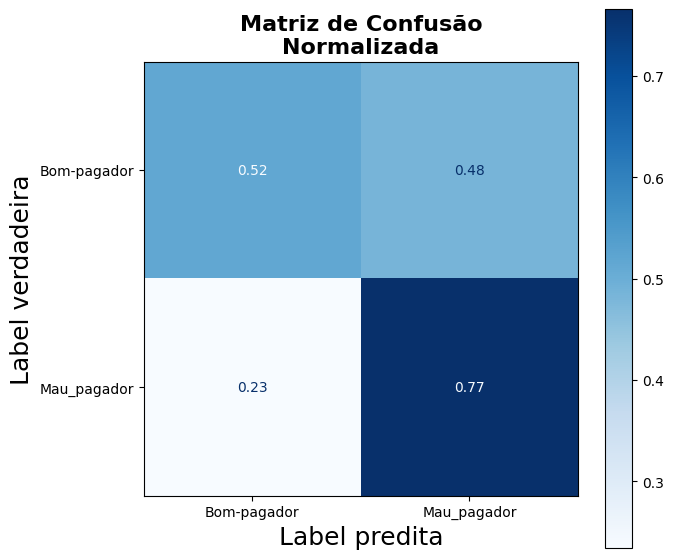


Classification Report

              precision    recall  f1-score   support

           0       0.69      0.52      0.59      4571
           1       0.61      0.77      0.68      4571

    accuracy                           0.64      9142
   macro avg       0.65      0.64      0.64      9142
weighted avg       0.65      0.64      0.64      9142


 ROC curve



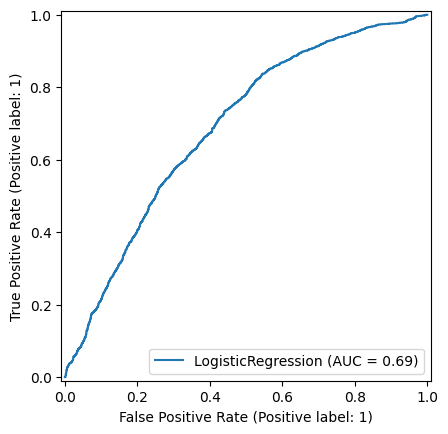

In [109]:
roda_modelo(modelo_logistico)

In [111]:
modelo_tree = DecisionTreeClassifier()


----------------------------- Resultados DecisionTreeClassifier() -----------------------------

Métrica KS: KstestResult(statistic=0.5929774666374973, pvalue=0.0, statistic_location=0.021739130434782608, statistic_sign=1)

 Confusion Matrix 



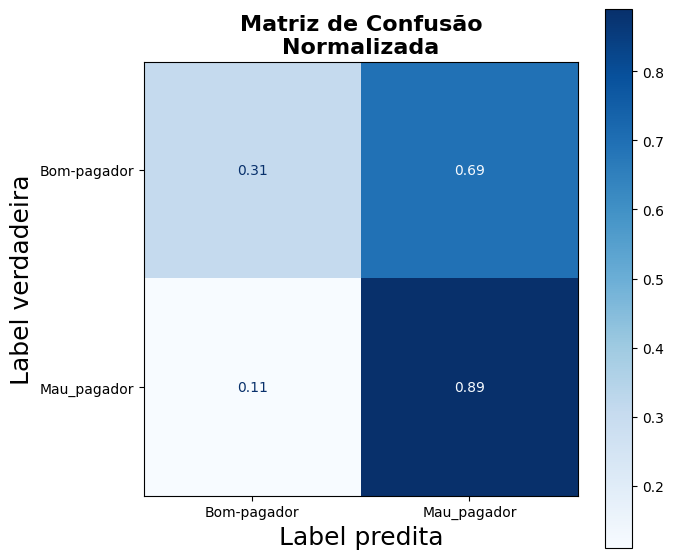


Classification Report

              precision    recall  f1-score   support

           0       0.74      0.31      0.43      4571
           1       0.56      0.89      0.69      4571

    accuracy                           0.60      9142
   macro avg       0.65      0.60      0.56      9142
weighted avg       0.65      0.60      0.56      9142


 ROC curve



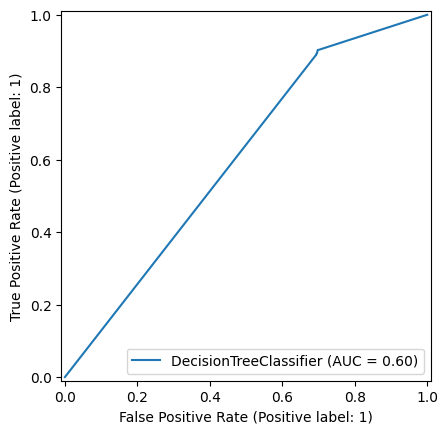

In [113]:
roda_modelo(modelo_tree)

In [115]:
modelo_xgb = GradientBoostingClassifier()


----------------------------- Resultados GradientBoostingClassifier() -----------------------------

Métrica KS: KstestResult(statistic=0.6250273463137169, pvalue=0.0, statistic_location=0.2999846306251279, statistic_sign=1)

 Confusion Matrix 



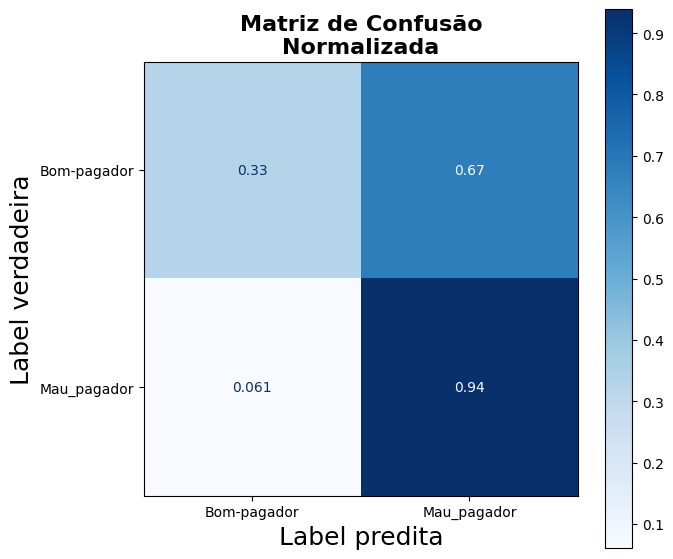


Classification Report

              precision    recall  f1-score   support

           0       0.84      0.33      0.47      4571
           1       0.58      0.94      0.72      4571

    accuracy                           0.63      9142
   macro avg       0.71      0.63      0.60      9142
weighted avg       0.71      0.63      0.60      9142


 ROC curve



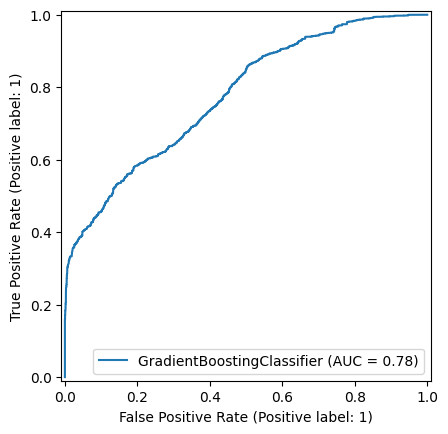

In [116]:
roda_modelo(modelo_xgb)

In [120]:
joblib.dump(modelo_xgb, 'xgb.joblib')

['xgb.joblib']